# Load Dataset

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet, load_csv

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay', '|avg B|']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())


✅ Successfully loaded data with shape: (3157920, 3)
                 time  orbital_decay   |avg B|
0 2023-01-01 00:00:00        16.6730  5.630000
1 2023-01-01 00:00:20        16.6730  5.633333
2 2023-01-01 00:00:40        16.6735  5.636667
3 2023-01-01 00:01:00        16.6740  5.640000
4 2023-01-01 00:01:20        16.6740  5.633333


# Create Lag features and correlate with target

Lag1 shifted by 5 minutes, Lag2 by 10 minutes, .. until 48h.

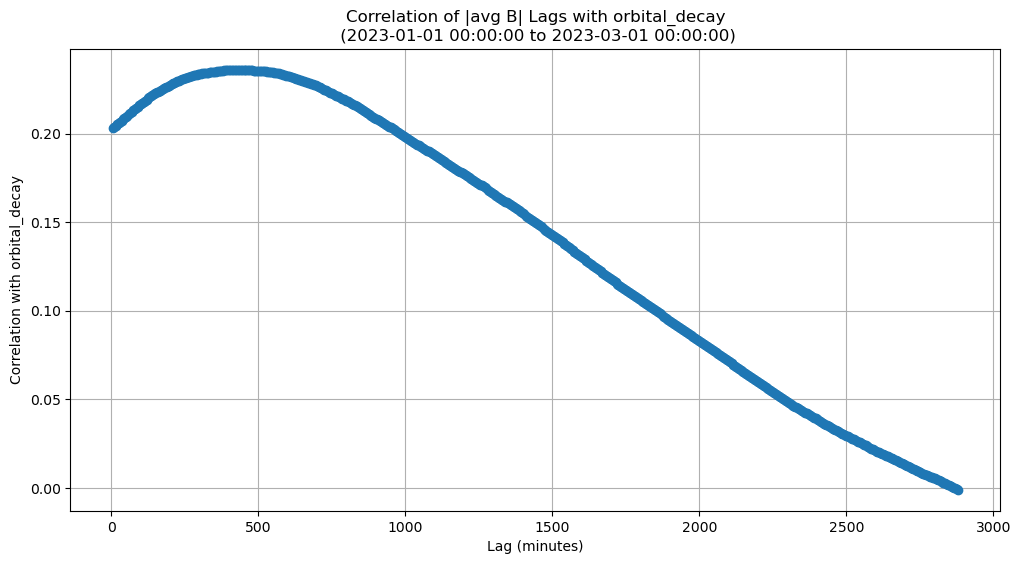

In [6]:
import numpy as np
from utils.lag_features import LagFeatures, fast_lag_correlation
from utils.plot_loader import create_subset
#-------------------Input-------------------------
feature = '|avg B|'
target = 'orbital_decay'
start_date = '2023-01-01 00:00:00'
end_date = '2023-03-01 00:00:00'
#-------------------------------------------------

# create subset
subset = create_subset(GFOC_data, start_date, end_date)
# create lag features
subset_lag = LagFeatures(subset[[feature]], lag_minutes=5, max_lag_hours=48).df
# add target column
subset_lag[target] = subset[target].values

# Get lag columns
lag_cols = [c for c in subset_lag.columns if c.startswith(f'{feature}_Lag')]

# Fast correlation
correlations = fast_lag_correlation(subset_lag, lag_cols, target)

# Plot
lags = [int(c.split('Lag')[1]) * 5 for c in lag_cols]  # in minutes
plt.figure(figsize=(12, 6))
plt.plot(lags, correlations, marker='o')
plt.xlabel('Lag (minutes)')
plt.ylabel(f'Correlation with {target}')
plt.title(f'Correlation of {feature} Lags with {target}\n ({start_date} to {end_date})')
plt.grid(True)
plt.show()

# Test for different subsets

Total subsets: 30, each with size: 105264 points = 36.55 days


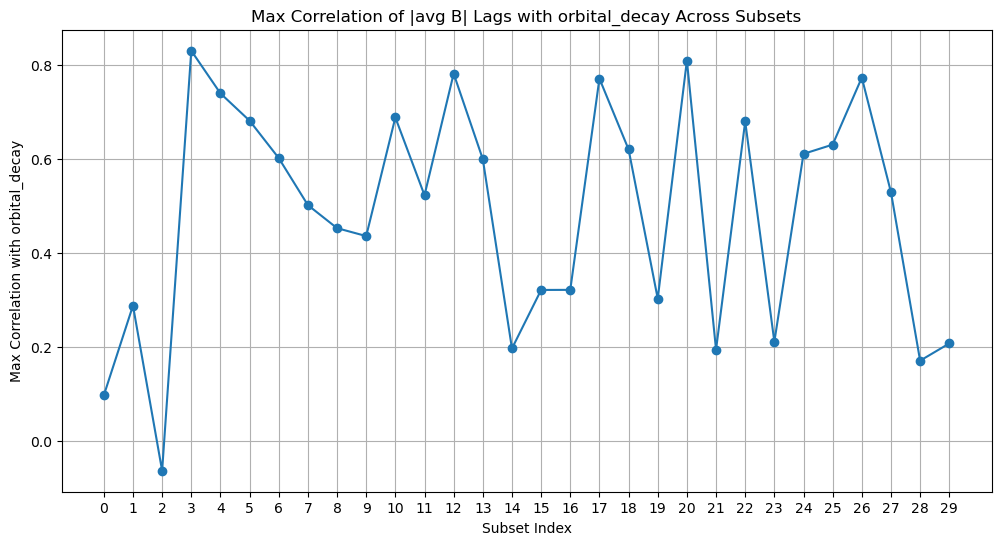

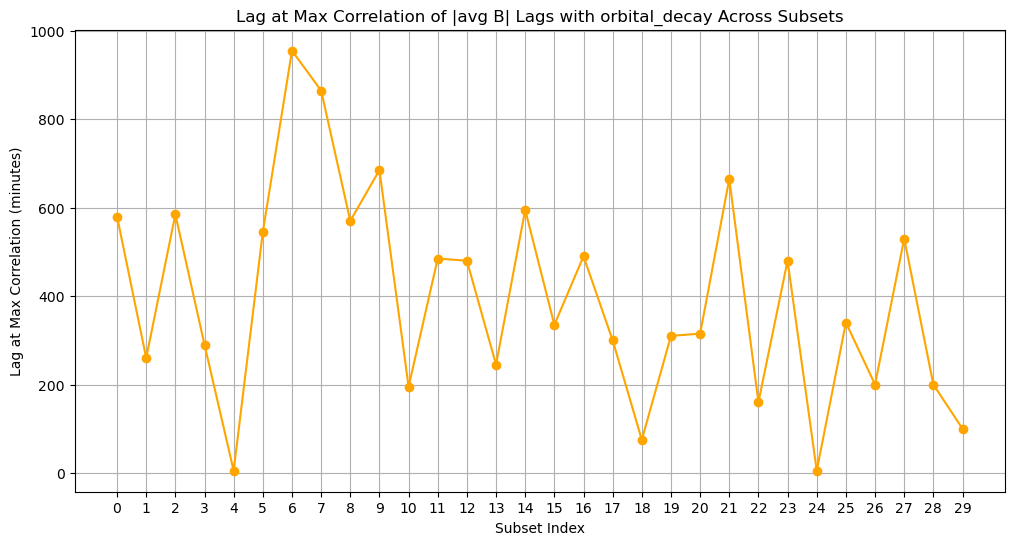

In [7]:
#-------------------Input-------------------------
feature = '|avg B|'
target = 'orbital_decay'
n = 30 # number of subsets to split the data into
#-------------------------------------------------

subset_size = len(GFOC_data[target]) // n
print(f"Total subsets: {n}, each with size: {subset_size} points = {subset_size / 120 / 24:.2f} days")
max_corr = [None] * n
lag_at_max = [None] * n
middle_data = [None] * n

for i in range(n):
    start_idx = i * subset_size
    # Make sure the last subset includes any remaining data
    end_idx = (i + 1) * subset_size if i < n - 1 else len(GFOC_data[target])
    subset = GFOC_data.iloc[start_idx:end_idx]

    # create lag features
    subset_lag = LagFeatures(subset[[feature]], lag_minutes=5, max_lag_hours=48).df
    # add target column
    subset_lag[target] = subset[target].values

    # Get lag columns
    lag_cols = [c for c in subset_lag.columns if c.startswith(f'{feature}_Lag')]

    # Fast correlation
    correlations = fast_lag_correlation(subset_lag, lag_cols, target)

    max_corr[i] = np.nanmax(correlations)
    lag_at_max[i] = (np.nanargmax(correlations) + 1) * 5
    middle_data[i] = subset['time'].iloc[len(subset) // 2]

# Plot max correlations
plt.figure(figsize=(12, 6))
plt.plot(range(n), max_corr, marker='o')
plt.xticks(range(n))
plt.xlabel('Subset Index')
plt.ylabel(f'Max Correlation with {target}')
plt.title(f'Max Correlation of {feature} Lags with {target} Across Subsets')
plt.grid(True)
plt.show()

# Plot lag at max correlations
plt.figure(figsize=(12, 6))
plt.plot(range(n), lag_at_max, marker='o', color='orange')
plt.xticks(range(n))
plt.xlabel('Subset Index')
plt.ylabel('Lag at Max Correlation (minutes)')
plt.title(f'Lag at Max Correlation of {feature} Lags with {target} Across Subsets')
plt.grid(True)
plt.show()

# Notes

- Vanessa pre-filters the data with Bz into three groups (Bz < 0, Bz < -5, Bz <9999)
- Depending on the strength of the event there are different propagation times for avg B.
- The correlation I calculated is still useful, as it shows the range of propagation times (lags) that occur in the dataset and therefore should be used in the model.